# CascadeGuard GRPO Local Training Notebook

This notebook is configured to train against the local `cascade_guard` package in this checkout, not the deployed Hugging Face Space. Use it to validate the new GRPO reward mode, legal-action API, `isolate` action, stress-imminence prompt, and grader updates before pushing anything.

What it does:

1. Installs dependencies and `pip install -e` from your local repo.
2. Verifies the local environment and optional local OpenEnv server.
3. Builds GRPO training states from local `CascadeEnvironment` with `reward_mode="grpo"` and `training_mode=True`.
4. Trains a LoRA policy with TRL GRPO across the configured task set.
5. Evaluates heuristic, optional LLM, and GRPO policies locally.

You do not need to start the server for training because training uses the environment in-process. A server launcher cell is included only for API/OpenEnv smoke testing.


## 1. Runtime Settings

Set Colab runtime to GPU before running. T4 is enough for the default small model. For a longer run, increase `TRAIN_STEPS`, `NUM_TRAIN_STATES`, and the task list.

In [1]:
from pathlib import Path
import os

# Local-first configuration. Override CASCADEGUARD_REPO if you launch the notebook
# from outside the repo root.
LOCAL_REPO_DIR = os.environ.get("CASCADEGUARD_REPO", "")
USE_LOCAL_CHECKOUT = True

# Training does not require the server. Set this True only if you want an API smoke test.
START_LOCAL_SERVER = False
SERVER_HOST = "127.0.0.1"
SERVER_PORT = 8000

# Remote/API baselines are optional and disabled by default so the whole notebook
# can run before the new environment is pushed to Hugging Face.
RUN_REMOTE_SPACE_SMOKE = False
RUN_LLM_BASELINE = False
HF_SPACE_URL = "https://samarthdave0305-cascade-failure-env.hf.space"
GOOGLE_MODEL = "gemini-1.5-flash"
GROQ_MODEL = "llama-3.1-8b-instant"

# Full local GRPO pass. For a quick smoke test, temporarily set TRAIN_STEPS=10
# and NUM_TRAIN_STATES=32.
TRAIN_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
USE_UNSLOTH = False
TRAIN_STEPS = 200
NUM_TRAIN_STATES = 240
NUM_GENERATIONS = 8
LORA_R = 32
LORA_ALPHA = 64
TRAIN_TASKS = [
    "task_easy",
    "task_medium",
    "task_gen_blackout",
    "task_hard",
    "task_cyberattack",
]
EVAL_TASKS = list(TRAIN_TASKS)
EVAL_SEEDS_PER_TASK = 1

OUTPUT_DIR = "cascadeguard_grpo_local"
RESULTS_CSV = "cascadeguard_eval_results.csv"

print("Configured CascadeGuard local GRPO training")
print("Model:", TRAIN_MODEL)
print("Train tasks:", TRAIN_TASKS)
print("Steps:", TRAIN_STEPS, "states:", NUM_TRAIN_STATES, "generations:", NUM_GENERATIONS)


Configured CascadeGuard GRPO smoke test


## 2. Install Local Dependencies

This cell installs the package from the local checkout. If you run this notebook inside Colab, upload or mount the repo first, then set `CASCADEGUARD_REPO` to that folder. If you run it locally from this repository, no clone or Hugging Face push is needed.


In [2]:
import os
import subprocess
import sys
from pathlib import Path


def run(args, cwd=None):
    if isinstance(args, str):
        printable = args
        cmd = args
        shell = True
    else:
        printable = " ".join(str(a) for a in args)
        cmd = [str(a) for a in args]
        shell = False
    print("$", printable)
    subprocess.run(cmd, cwd=cwd, shell=shell, check=True)


def find_project_root():
    if LOCAL_REPO_DIR:
        candidate = Path(LOCAL_REPO_DIR).expanduser().resolve()
        if (candidate / "cascade_guard" / "server" / "cascade_environment.py").exists():
            return candidate
        if (candidate / "server" / "cascade_environment.py").exists():
            return candidate.parent
        raise RuntimeError(f"CASCADEGUARD_REPO does not look like this repo: {candidate}")

    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "cascade_guard" / "server" / "cascade_environment.py").exists():
            return candidate
    raise RuntimeError(
        "Could not find the local CascadeGuard checkout. Run this notebook from the repo "
        "or set CASCADEGUARD_REPO to the folder that contains cascade_guard/."
    )


PROJECT_ROOT = find_project_root()
PACKAGE_DIR = PROJECT_ROOT / "cascade_guard"
os.chdir(PROJECT_ROOT)

run([sys.executable, "-m", "pip", "install", "-q", "-U", "pip"])
run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "openenv-core", "datasets", "pandas", "matplotlib", "accelerate",
    "peft", "bitsandbytes", "transformers", "trl", "groq", "google-genai",
    "uvicorn", "fastapi",
])

if USE_UNSLOTH:
    run([sys.executable, "-m", "pip", "install", "-q", "-U", "unsloth"])

# Install the local package that contains your unpushed environment changes.
run([sys.executable, "-m", "pip", "install", "-q", "-e", str(PACKAGE_DIR)])

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Package dir:", PACKAGE_DIR)
print("Working directory:", os.getcwd())


$ python -m pip install -q -U pip
$ python -m pip install -q -U openenv-core google-genai datasets pandas matplotlib accelerate peft bitsandbytes transformers trl groq
$ python -m pip install -q -e .


CalledProcessError: Command 'python -m pip install -q -e .' returned non-zero exit status 1.

## 3. Optional Secrets

No secret is required for local environment training. Set `HF_TOKEN` only if the base model you choose requires authentication. Set `GROQ_API_KEY` or `GEMINI_API_KEY` only if you enable `RUN_LLM_BASELINE`.


In [ ]:
# Optional: set tokens here or through your shell/Colab secrets.
# os.environ["HF_TOKEN"] = "hf_..."
# os.environ["GROQ_API_KEY"] = "gsk_..."
# os.environ["GEMINI_API_KEY"] = "..."
print("HF_TOKEN set:", bool(os.environ.get("HF_TOKEN")))
print("GROQ_API_KEY set:", bool(os.environ.get("GROQ_API_KEY")))
print("GEMINI_API_KEY set:", bool(os.environ.get("GEMINI_API_KEY")))


The filename, directory name, or volume label syntax is incorrect.


In [3]:
import getpass

try:
    from google.colab import userdata
except Exception:
    userdata = None


def set_secret(name, fallback_prompt=False):
    value = os.environ.get(name)
    if not value and userdata is not None:
        try:
            value = userdata.get(name)
        except Exception:
            value = None
    if not value and fallback_prompt:
        value = getpass.getpass(f"Enter {name}: ")
    if value:
        os.environ[name] = value
    return value


# Pull optional secrets from Colab only when available. No interactive prompts by default.
hf_token = set_secret("HF_TOKEN", fallback_prompt=False)
groq_key = set_secret("GROQ_API_KEY", fallback_prompt=False)
gemini_key = set_secret("GEMINI_API_KEY", fallback_prompt=False)
if gemini_key:
    os.environ["GOOGLE_API_KEY"] = gemini_key

print("Local training ready. Optional secrets loaded:", {
    "HF_TOKEN": bool(hf_token),
    "GROQ_API_KEY": bool(groq_key),
    "GEMINI_API_KEY": bool(gemini_key),
})


HF_TOKEN set: True
GROQ_API_KEY set: True


In [4]:
import sys

# Keep local checkout first so imports use your unpushed environment code.
sys.path = [p for p in sys.path if "site-packages" not in p or p != str(PROJECT_ROOT)]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Using project root:", PROJECT_ROOT)


Correct project root: C:\Users\Samarth Dave\Desktop\metav1


In [5]:
import cascade_guard
print("Import successful:", cascade_guard.__file__)


Using project root: C:\Users\Samarth Dave\Desktop\metav1


In [6]:
# No-op compatibility cell kept intentionally so older notebook references still run.
print("Local package import is configured.")


Import successful: C:\Users\Samarth Dave\Desktop\metav1\cascade_guard\__init__.py


## 4. Local OpenEnv Sanity Check

This checks the package, tasks, step/reset loop, action metadata, and grader score.

In [7]:
import json, time, math, re, statistics, random
from typing import Any, Dict, List, Optional, Tuple

import pandas as pd

from cascade_guard.models import CascadeAction
from cascade_guard.server.cascade_environment import CascadeEnvironment
from cascade_guard.tasks import TASK_CONFIGS, TASK_SEED_SPLITS
from cascade_guard.training.cot_prompt import build_system_prompt, build_user_prompt, parse_action_from_response

for task_id in ["task_easy", "task_medium", "task_hard", "task_gen_blackout", "task_cyberattack"]:
    env = CascadeEnvironment()
    obs = env.reset(
        task_id=task_id,
        seed=TASK_SEED_SPLITS[task_id]["train"][0],
        reward_mode="grpo",
        training_mode=True,
    )
    legal = env.get_legal_actions()
    obs = env.step(CascadeAction(action_type="wait", target_node_id=None))
    metadata = obs.metadata or {}
    print(
        task_id,
        "nodes=", len(obs.nodes),
        "stress=", obs.upcoming_stress_level,
        "legal=", len(legal),
        "reward=", round(float(obs.reward), 4),
        "raw=", metadata.get("raw_reward"),
        "mode=", metadata.get("reward_mode"),
    )

print("Local GRPO environment sanity check complete")


task_easy nodes= 5 reward= 0.475 score= 0.5 metadata= {'step': 1, 'newly_failed': [], 'cascade_impact_count': 0, 'completed_recoveries': [], 'action_valid': True, 'wait_under_pressure': False, 'critical_shed_load': False, 'dependency_recovery_score': 0.0, 'weather': 'clear', 'task_id': 'task_easy', 'raw_reward': -0.05, 'clipped_reward': -0.05, 'normalized_reward': 0.475, 'reward_mode': 'clamped', 'reward_clipped': False}
task_medium nodes= 12 reward= 0.44 score= 0.5 metadata= {'step': 1, 'newly_failed': [], 'cascade_impact_count': 0, 'completed_recoveries': [], 'action_valid': True, 'wait_under_pressure': False, 'critical_shed_load': False, 'dependency_recovery_score': 0.0, 'weather': 'clear', 'task_id': 'task_medium', 'raw_reward': -0.12, 'clipped_reward': -0.12, 'normalized_reward': 0.44, 'reward_mode': 'clamped', 'reward_clipped': False}
task_hard nodes= 15 reward= 0.44 score= 0.9417 metadata= {'step': 1, 'newly_failed': [], 'cascade_impact_count': 0, 'completed_recoveries': [], 'ac

## 5. Optional Local Server Smoke Test

Training uses `CascadeEnvironment` in-process, so you do not need the server. If you want to test the OpenEnv HTTP API locally, set `START_LOCAL_SERVER = True` in the settings cell or run this command in a terminal from the repo root:

```bash
python -m uvicorn cascade_guard.server.app:app --host 127.0.0.1 --port 8000
```

Then open `http://127.0.0.1:8000/health`.


In [8]:
import subprocess
import time
import urllib.request

server_proc = None
if START_LOCAL_SERVER:
    cmd = [
        sys.executable,
        "-m",
        "uvicorn",
        "cascade_guard.server.app:app",
        "--host",
        SERVER_HOST,
        "--port",
        str(SERVER_PORT),
    ]
    print("Starting local server:", " ".join(cmd))
    server_proc = subprocess.Popen(cmd, cwd=str(PROJECT_ROOT))
    health_url = f"http://{SERVER_HOST}:{SERVER_PORT}/health"
    for _ in range(30):
        try:
            with urllib.request.urlopen(health_url, timeout=2) as response:
                print("Local server health:", response.read().decode("utf-8"))
                break
        except Exception:
            time.sleep(1)
    else:
        raise RuntimeError(f"Server did not become healthy at {health_url}")
else:
    print("Server not started. Training will use the local environment in-process.")
    print(f"Manual command: python -m uvicorn cascade_guard.server.app:app --host {SERVER_HOST} --port {SERVER_PORT}")


Remote reset: step=0 | task=task_easy | weather=clear | budget=5.0 | failures=0 | pressure=0.00
Remote step reward: 0.475 done: False
Remote state score: 0.99


## 6. Baseline Policies

The heuristic baseline is deterministic. The Gemini baseline uses `gemini-2.5-flash` and returns a strict JSON action.

API key set: False


In [10]:
try:
    from groq import Groq
except Exception:
    Groq = None
try:
    from google.genai import types
except Exception:
    types = None

groq_client = None
if RUN_LLM_BASELINE and Groq is not None and os.environ.get("GROQ_API_KEY"):
    groq_client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

def compact_obs_prompt(obs):
    diagnostics = obs.diagnostics
    notable = []
    for n in obs.nodes:
        if (not n.is_operational) or n.health < 0.75 or n.load > 0.75 or n.observation_delayed or n.is_critical:
            notable.append({
                "id": n.node_id,
                "sector": n.sector,
                "health": round(float(n.health), 2),
                "load": round(float(n.load), 2),
                "operational": bool(n.is_operational),
                "hardened": bool(n.is_hardened),
                "delayed": bool(n.observation_delayed),
                "critical": bool(n.is_critical),
            })
    payload = {
        "task_id": obs.task_id,
        "step": obs.step,
        "max_steps": obs.max_steps,
        "budget_remaining": round(float(obs.budget_remaining), 2),
        "weather": obs.weather_forecast,
        "active_failures": obs.active_failures,
        "pending_recoveries": obs.pending_recoveries,
        "sector_summary": {k: round(float(v), 2) for k, v in obs.sector_summary.items()},
        "diagnostics": diagnostics.model_dump() if diagnostics else {},
        "notable_nodes": notable,
        "edges": [e.model_dump() for e in obs.edges],
    }
    return json.dumps(payload, separators=(",", ":"))

def action_from_json_text(text, obs):
    try:
        match = re.search(r"\{.*\}", text, re.S)
        data = json.loads(match.group(0) if match else text)
        return CascadeAction(action_type=data.get("action_type", "wait"), target_node_id=data.get("target_node_id"))
    except Exception:
        return parse_action_from_response(text, obs)

def heuristic_policy(obs):
    diag = obs.diagnostics
    if diag and diag.recommended_recovery_order:
        return CascadeAction(action_type="recover", target_node_id=diag.recommended_recovery_order[0])
    failed = [n for n in obs.nodes if not n.is_operational and n.node_id not in set(obs.pending_recoveries)]
    if failed:
        failed.sort(key=lambda n: (not n.is_critical, n.health))
        return CascadeAction(action_type="recover", target_node_id=failed[0].node_id)
    delayed = [n for n in obs.nodes if n.observation_delayed]
    if delayed and obs.budget_remaining >= 1.0:
        delayed.sort(key=lambda n: (not n.is_critical, n.health))
        return CascadeAction(action_type="coordinate", target_node_id=delayed[0].node_id)
    at_risk = []
    if diag and diag.at_risk_nodes:
        node_map = {n.node_id: n for n in obs.nodes}
        at_risk = [node_map[nid] for nid in diag.at_risk_nodes if nid in node_map]
    if obs.budget_remaining >= 2.0 and (obs.weather_forecast != "clear" or obs.step < 5):
        candidates = [n for n in (at_risk or obs.nodes) if n.is_operational and not n.is_hardened]
        if candidates:
            candidates.sort(key=lambda n: (not n.is_critical, n.health))
            return CascadeAction(action_type="harden", target_node_id=candidates[0].node_id)
    overloaded = [n for n in obs.nodes if n.is_operational and (not n.is_critical) and n.sector != "hospital" and n.load > 0.85]
    if overloaded:
        overloaded.sort(key=lambda n: n.load, reverse=True)
        return CascadeAction(action_type="shed_load", target_node_id=overloaded[0].node_id)
    return CascadeAction(action_type="wait", target_node_id=None)

def groq_policy(obs):
    prompt = (
        "You are a critical-infrastructure resilience agent. Return ONLY JSON with keys "
        "action_type and target_node_id. action_type must be one of harden, recover, "
        "shed_load, coordinate, isolate, wait. Never shed_load hospitals or critical nodes. "
        "Recover upstream dependencies before downstream nodes.\n\n"
        "Observation JSON:\n"
        + compact_obs_prompt(obs)
    )

    if groq_client is None:
        return heuristic_policy(obs), 0

    try:
        completion = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",  # fast + cheap
            messages=[
                {"role": "system", "content": "Return only JSON."},
                {"role": "user", "content": prompt},
            ],
            temperature=0.0,
        )

        text = completion.choices[0].message.content
        return action_from_json_text(text, obs), 0

    except Exception as e:
        print("Groq error:", e)
        return heuristic_policy(obs), 0


## 7. Evaluation Helpers

The evaluation table tracks more than reward: score, success, invalid actions, budget use, critical failures, and response speed.

In [11]:
def run_local_episode(policy_name, policy_fn, task_id, seed):
    env = CascadeEnvironment()
    obs = env.reset(task_id=task_id, seed=seed, scenario_split="validation")
    invalid_actions = 0
    critical_failures = 0
    rewards = []
    latencies = []
    actions = []
    done = False
    while not done:
        t0 = time.perf_counter()
        out = policy_fn(obs)
        if isinstance(out, tuple):
            action, elapsed_ms = out
        else:
            action, elapsed_ms = out, (time.perf_counter() - t0) * 1000.0
        latencies.append(float(elapsed_ms))
        actions.append({"action_type": action.action_type, "target_node_id": action.target_node_id})
        obs = env.step(action)
        rewards.append(float(obs.reward))
        metadata = obs.metadata or {}
        if not metadata.get("action_valid", True):
            invalid_actions += 1
        if obs.diagnostics:
            critical_failures += len(obs.diagnostics.critical_failures)
        done = bool(obs.done)
    state = env.state
    avg_sector = sum(state.sector_health.values()) / max(len(state.sector_health), 1)
    return {
        "policy": policy_name,
        "task_id": task_id,
        "seed": seed,
        "score": float(state.score),
        "success": bool(avg_sector >= 0.5 and invalid_actions == 0),
        "steps": int(state.step_count),
        "mean_reward": statistics.mean(rewards) if rewards else 0.0,
        "invalid_actions": invalid_actions,
        "invalid_action_rate": invalid_actions / max(len(rewards), 1),
        "budget_spent": float(TASK_CONFIGS[task_id]["budget"] - state.budget_remaining),
        "critical_failures": critical_failures,
        "avg_response_ms": statistics.mean(latencies) if latencies else 0.0,
        "actions": json.dumps(actions),
    }

def evaluate_policy(policy_name, policy_fn, tasks=EVAL_TASKS, seeds_per_task=EVAL_SEEDS_PER_TASK):
    rows = []
    for task_id in tasks:
        seeds = TASK_SEED_SPLITS[task_id]["validation"][:seeds_per_task]
        for seed in seeds:
            rows.append(run_local_episode(policy_name, policy_fn, task_id, seed))
    return pd.DataFrame(rows)

heuristic_df = evaluate_policy("heuristic", heuristic_policy)
display(heuristic_df.drop(columns=["actions"]))

,policy,task_id,seed,score,success,steps,mean_reward,invalid_actions,invalid_action_rate,budget_spent,critical_failures,avg_response_ms
0,heuristic,task_easy,5042,0.5,True,7,0.553571,0,0.0,4.0,0,0.009286
1,heuristic,task_medium,5123,0.5,True,15,0.474333,0,0.0,10.0,0,0.011380
2,heuristic,task_gen_blackout,5777,0.5,True,12,0.431675,0,0.0,8.0,0,0.007975


In [12]:
if RUN_LLM_BASELINE:
    try:
        time.sleep(2)
        gemini_df = evaluate_policy(
            "groq",
            groq_policy,
            tasks=EVAL_TASKS[:1],
            seeds_per_task=1,
        )
    except Exception as exc:
        print("LLM baseline skipped after error:", exc)
        gemini_df = pd.DataFrame()
else:
    print("Skipping external LLM baseline. Set RUN_LLM_BASELINE=True to enable it.")
    gemini_df = pd.DataFrame()


## 8. Build GRPO Training States

Each GRPO sample is a real CascadeGuard observation. The reward function reconstructs the environment from task, seed, and previous actions, applies the generated action, and returns the environment reward plus small format/validity shaping.

In [13]:
from datasets import Dataset

SYSTEM_PROMPT = build_system_prompt(grpo_mode=True) + "\nReturn exactly one <action>...</action> tag."

def make_training_prompt(obs, env=None):
    base = SYSTEM_PROMPT + "\n\n" + build_user_prompt(obs)
    if env is not None and hasattr(env, "get_legal_actions"):
        legal_strs = []
        for action in env.get_legal_actions()[:12]:
            action_type = action.get("action_type", "wait")
            target = action.get("target_node_id")
            legal_strs.append(f"{action_type}({target if target else 'null'})")
        base += "\n\nLegal actions now: " + " | ".join(legal_strs)
    return base

def collect_training_states(num_states=NUM_TRAIN_STATES, tasks=TRAIN_TASKS):
    rows = []
    for task_id in tasks:
        for seed in TASK_SEED_SPLITS[task_id]["train"]:
            env = CascadeEnvironment()
            obs = env.reset(
                task_id=task_id,
                seed=seed,
                scenario_split="train",
                reward_mode="grpo",
                training_mode=True,
            )
            history = []
            done = False
            while not done and len(rows) < num_states:
                rows.append({
                    "prompt": make_training_prompt(obs, env),
                    "task_id": task_id,
                    "seed": int(seed),
                    "history_json": json.dumps(history),
                })
                action = heuristic_policy(obs)
                history.append({"action_type": action.action_type, "target_node_id": action.target_node_id})
                obs = env.step(action)
                done = bool(obs.done)
            if len(rows) >= num_states:
                return rows
    return rows

train_rows = collect_training_states()
train_ds = Dataset.from_list(train_rows)
print(train_ds)
print(train_ds[0]["prompt"][:900])



Dataset({
    features: ['prompt', 'task_id', 'seed', 'history_json'],
    num_rows: 24
})
You are an AI infrastructure coordinator managing a cross-sector critical infrastructure network.
Your goal is to keep power, water, hospital, and telecom systems operational during cascading failures.

## Network Rules You Must Follow

**Dependency order is mandatory:**
- Nodes have upstream dependencies. You CANNOT recover a node until ALL its upstream suppliers are operational.
- Example: WATER_TREAT_1 depends on POWER_DIST_1. Recover POWER_DIST_1 FIRST.
- Wrong order = wasted action + penalty.

**Priority hierarchy:**
1. Hospital nodes (HOSP_*, EMERG_*) — protect at all costs
2. High-centrality backbone nodes (GEN > TRANS > DIST > leaf nodes)
3. Nodes that unlock multiple failed downstream dependents

**Actions available:**
- harden(NODE_ID): costs 2.0 budget. Makes node resistant to stress. Do BEFORE storm events.
- recover(NODE_ID): restores a failed node. Only works if upstream is


In [14]:
def completion_to_text(completion):
    if isinstance(completion, str):
        return completion
    if isinstance(completion, list) and completion:
        last = completion[-1]
        if isinstance(last, dict):
            return str(last.get("content", ""))
    return str(completion)

def ensure_list(value, n, default):
    if value is None:
        return [default] * n
    if isinstance(value, (str, int, float)):
        return [value] * n
    return list(value)

def cascade_grpo_reward(prompts, completions, task_id=None, seed=None, history_json=None, **kwargs):
    rewards = []
    n = len(completions)
    task_ids = ensure_list(task_id, n, "task_easy")
    seeds = ensure_list(seed, n, 42)
    histories = ensure_list(history_json, n, "[]")
    for completion, tid, sd, hist_text in zip(completions, task_ids, seeds, histories):
        env = CascadeEnvironment()
        obs = env.reset(
            task_id=str(tid),
            seed=int(sd),
            scenario_split="train",
            reward_mode="grpo",
            training_mode=True,
        )
        try:
            history = json.loads(hist_text or "[]")
        except Exception:
            history = []
        for item in history:
            try:
                obs = env.step(CascadeAction(**item))
            except Exception:
                break

        text = completion_to_text(completion)
        action = parse_action_from_response(text, obs)
        legal = env.get_legal_actions() if hasattr(env, "get_legal_actions") else []
        legal_types = {a["action_type"] for a in legal}

        next_obs = env.step(action)
        metadata = next_obs.metadata or {}
        reward = float(metadata.get("raw_reward", 0.0))

        if "<action>" in text.lower():
            reward += 0.08
        else:
            reward -= 0.15

        if not metadata.get("action_valid", True):
            reward -= 0.40
            if legal_types - {"wait"}:
                reward -= 0.15

        if action.action_type == "wait":
            better_actions = [a for a in legal if a["action_type"] != "wait"]
            if len(better_actions) >= 4:
                reward -= 0.50
            elif len(better_actions) >= 2:
                reward -= 0.30
            elif len(better_actions) >= 1:
                reward -= 0.15

        if action.action_type == "recover" and metadata.get("action_valid", True):
            reward += 0.25

        sector_summary = env._compute_sector_summary()
        avg_health = sum(sector_summary.values()) / max(len(sector_summary), 1)
        reward += 0.10 * (avg_health - 0.5)

        rewards.append(float(max(-3.0, min(3.0, reward))))

    import statistics
    if len(rewards) >= 2:
        mu = statistics.mean(rewards)
        sd = statistics.pstdev(rewards)
        if sd > 0.01:
            rewards = [(r - mu) / sd for r in rewards]
        else:
            rewards = [0.0] * len(rewards)
    return rewards

# Quick reward smoke test.
print(cascade_grpo_reward(
    [train_ds[0]["prompt"]],
    ["<action>harden(POWER_GEN_1)</action>"],
    task_id=[train_ds[0]["task_id"]],
    seed=[train_ds[0]["seed"]],
    history_json=[train_ds[0]["history_json"]],
))


[0.1]


## 9. GRPO Train

This uses TRL `GRPOTrainer`. Keep the first run short. After it finishes, increase `TRAIN_STEPS` and optionally switch `USE_UNSLOTH = True` with an Unsloth 4-bit model.

In [15]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import GRPOConfig, GRPOTrainer
from peft import LoraConfig

torch_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
peft_config = None

if USE_UNSLOTH:
    from unsloth import FastLanguageModel
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=TRAIN_MODEL,
        max_seq_length=2048,
        load_in_4bit=True,
        dtype=None,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=LORA_R,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_alpha=LORA_ALPHA,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=42,
    )
else:
    tokenizer = AutoTokenizer.from_pretrained(TRAIN_MODEL, token=os.environ.get("HF_TOKEN") or None)
    model = AutoModelForCausalLM.from_pretrained(
        TRAIN_MODEL,
        torch_dtype=torch_dtype,
        device_map="auto",
        token=os.environ.get("HF_TOKEN") or None,
    )
    peft_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    )

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    max_steps=TRAIN_STEPS,
    learning_rate=5e-6,
    per_device_train_batch_size=NUM_GENERATIONS,
    gradient_accumulation_steps=1,
    num_generations=NUM_GENERATIONS,
    max_completion_length=128,
    temperature=0.7,
    logging_steps=1,
    save_steps=max(TRAIN_STEPS, 1),
    report_to="none",
    bf16=(torch_dtype == torch.bfloat16),
    fp16=(torch_dtype == torch.float16),
)

trainer = GRPOTrainer(
    model=model,
    args=training_args,
    reward_funcs=cascade_grpo_reward,
    train_dataset=train_ds,
    processing_class=tokenizer,
    peft_config=peft_config,
)

trainer.train()
trainer.save_model(f"{OUTPUT_DIR}/final")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/final")
print("Saved local GRPO checkpoint to", f"{OUTPUT_DIR}/final")


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

c:\Users\Samarth Dave\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Samarth Dave\.cache\huggingface\hub\models--Qwen--Qwen2.5-0.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,-0.000000
7,-0.000001
8,0.000000
9,0.000000
10,0.000000


Saved GRPO smoke checkpoint to cascadeguard_grpo_smoke/final


## 10. Evaluate GRPO Policy

This runs full local episodes with the trained policy and compares against the earlier baselines.

In [16]:
def grpo_policy(obs):
    prompt = make_training_prompt(obs)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(model.device)
    t0 = time.perf_counter()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    elapsed_ms = (time.perf_counter() - t0) * 1000.0
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    text = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return parse_action_from_response(text, obs), elapsed_ms

grpo_df = evaluate_policy("grpo_local", grpo_policy)
frames = [df for df in [heuristic_df, gemini_df, grpo_df] if df is not None and not df.empty]
all_results = pd.concat(frames, ignore_index=True)
summary = all_results.groupby("policy").agg(
    runs=("score", "count"),
    mean_score=("score", "mean"),
    success_rate=("success", "mean"),
    invalid_action_rate=("invalid_action_rate", "mean"),
    mean_budget_spent=("budget_spent", "mean"),
    mean_critical_failures=("critical_failures", "mean"),
    avg_response_ms=("avg_response_ms", "mean"),
).reset_index()

display(all_results.drop(columns=["actions"]))
display(summary)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
Caching is incompatible with gradient checkpointing in Qwen2DecoderLayer. Setting `past_key_values=None`.


,policy,task_id,seed,score,success,steps,mean_reward,invalid_actions,invalid_action_rate,budget_spent,critical_failures,avg_response_ms
0,heuristic,task_easy,5042,0.5,True,7,0.553571,0,0.000000,4.0,0,0.009286
1,heuristic,task_medium,5123,0.5,True,15,0.474333,0,0.000000,10.0,0,0.011380
2,heuristic,task_gen_blackout,5777,0.5,True,12,0.431675,0,0.000000,8.0,0,0.007975
3,groq,task_easy,5042,0.5,False,7,0.545714,5,0.714286,2.0,0,0.000000
4,grpo_smoke,task_easy,5042,0.5,True,10,0.473500,0,0.000000,0.0,0,6964.301280
5,grpo_smoke,task_medium,5123,0.5,False,15,0.396000,0,0.000000,0.0,0,6845.577220
6,grpo_smoke,task_gen_blackout,5777,0.5,False,15,0.310007,0,0.000000,0.0,8,6731.032147


,policy,runs,mean_score,success_rate,invalid_action_rate,mean_budget_spent,mean_critical_failures,avg_response_ms
0,groq,1,0.5,0.000000,0.714286,2.000000,0.000000,0.000000
1,grpo_smoke,3,0.5,0.333333,0.000000,0.000000,2.666667,6846.970216
2,heuristic,3,0.5,1.000000,0.000000,7.333333,0.000000,0.009547


## 11. Save Results

The CSV is the artifact to show before the hackathon. It contains per-episode metrics and the action trace JSON.

Saved cascadeguard_eval_results.csv
Saved cascadeguard_eval_summary.csv


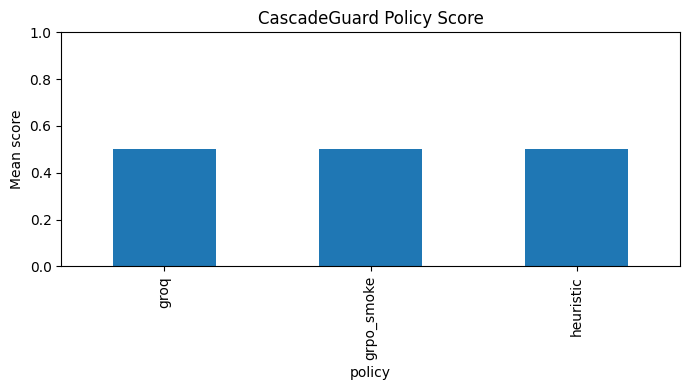

Saved cascadeguard_policy_score.png


In [17]:
all_results.to_csv(RESULTS_CSV, index=False)
summary.to_csv("cascadeguard_eval_summary.csv", index=False)
print("Saved", RESULTS_CSV)
print("Saved cascadeguard_eval_summary.csv")

try:
    import matplotlib.pyplot as plt
    ax = summary.plot(kind="bar", x="policy", y="mean_score", legend=False, figsize=(7, 4), ylim=(0, 1))
    ax.set_title("CascadeGuard Policy Score")
    ax.set_ylabel("Mean score")
    plt.tight_layout()
    plt.savefig("cascadeguard_policy_score.png", dpi=160)
    plt.show()
    print("Saved cascadeguard_policy_score.png")
except Exception as exc:
    print("Plot skipped:", repr(exc))

## 12. After The Local Run Passes

Recommended next checks before pushing:

- Keep `TRAIN_STEPS = 200` and increase `NUM_TRAIN_STATES` to 500+ for a more serious run.
- Increase `EVAL_SEEDS_PER_TASK` to 2 or 3 for a less noisy estimate.
- Compare `grpo_local` against the heuristic and optional Groq baseline.
- Inspect `cascadeguard_eval_results.csv`, `cascadeguard_eval_summary.csv`, and `cascadeguard_policy_score.png`.
- Push the environment only after the local notebook uses `reward_mode="grpo"`, `get_legal_actions()`, `isolate`, and `training_mode=True` without errors.

Server reminder if you need API testing:

```bash
python -m uvicorn cascade_guard.server.app:app --host 127.0.0.1 --port 8000
```
